# The Kallman filter on 2D stock pricing data project

## Steps:

*  **Step 1**: Understand the Kalman filter and its utility
*  **Step 2**: Librairies imports (yfinance)
*  **Step 3**: Build a profitable trading strategy
*  **Step 4**: Conclusion








## Step 1:  **_Kalman filter and its utility_**

## 1. State Space Model

The Kalman filter assumes that the market has a hidden state:

$
x_t =
\begin{bmatrix}
p_t \\
v_t
\end{bmatrix}
$

where:

- $p_t$: estimated true price
- $v_t$: price velocity ( trend )


The observed market price is:

$ z_t = p_t + \epsilon_t$

where:

- $z_t$: observed price
- $\epsilon_t$: measurement noise

---

# 2. State Transition Model

The hidden state evolves as:

$x_t = F x_{t-1} + w_t$

with:

$
F =
\begin{bmatrix}
1 & 1 \\
0 & 1
\end{bmatrix}
$


Therefore:

$p_t = p_{t-1}+v_{t-1}$

$v_t = v_{t-1}$


where:

- $w_t$: process noise


---

# 3. Observation Model

The market only provides the price:

$z_t = Hx_t+\epsilon_t$


where:

$
H =
\begin{bmatrix}
1&0
\end{bmatrix}
$


and:

- $\epsilon_t$: observation noise
- $R$: measurement noise covariance


---

# 4. Kalman Filter Algorithm


## Prediction Step

Estimate the next state:

$
\hat{x}_{t|t-1}=F\hat{x}_{t-1|t-1}
$


Predict uncertainty:

$
P_{t|t-1}
=
FP_{t-1|t-1}F^T+Q
$


where:

- $P$: state covariance ( uncertainty )
- $Q$: process noise covariance

---

## Update Step


Prediction error:

$y_t=z_t-H\hat{x}_{t|t-1}$


Innovation covariance:

$S_t=HP_{t|t-1}H^T+R$


Kalman gain:

$K_t=P_{t|t-1}H^TS_t^{-1}$


Update state:

$
\hat{x}_{t|t}
=
\hat{x}_{t|t-1}
+
K_ty_t
$


Update uncertainty:

$
P_{t|t}
=
(I-K_tH)P_{t|t-1}
$


---

# 5. Trading Features Extracted

After filtering:

## Estimated price

$\hat{p}_t = x_t[0]$


## Trend velocity

$\hat{v}_t=x_t[1]$


## Price deviation

$d_t=z_t-\hat{p}_t$


These become trading signals.


---

# 6. Trading Logic Example


## Long signal

$d_t < 0$

( price below estimated value )

AND

$
\hat{v}_t>0
$

( upward trend )


Decision: $ -> BUY$

---

## Short signal

$d_t > 0$

( price above estimated value )

AND

$\hat{v}_t<0$

( downward trend )


Decision: $-> SELL$


---

# 7. Risk Management Layer


Position size:

$Position=\frac{Risk}{StopLossDistance \times ValuePerPoint}$

Stop loss:

$
SL = Entry \pm k \times ATR
$


where:

- $k$: volatility multiplier
- ATR: average true range




## Step 2:  **_Librairies imports_**

In [1]:
pip install yfinance

In [25]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [112]:
data_HCOLV = yf.download(
    "SPY",
    start="2023-05-01",
    end="2026-06-23",
    interval="1d"
)
split = int(len(data_HCOLV)*0.8)    # 80 % for training and 20 % for testing

train = data_HCOLV[:split]
test = data_HCOLV[split:]

train_prices2D = train["Close"].values.flatten()
train_prices2D_index = train.index.values

test_prices2D = test["Close"].values.flatten()
test_prices2D_index = test.index.values

prices2D = np.append(train_prices2D, test_prices2D)

print(data_HCOLV.tail(5))

/tmp/ipykernel_4977/72645891.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_HCOLV = yf.download(
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2026-06-15  752.890381  754.735603  749.828262  749.917997  60176400
2026-06-16  748.401978  753.498832  747.953122  752.611105  67093100
2026-06-17  739.056030  750.217279  737.320450  749.359442  85945200
2026-06-18  746.739990  748.229980  743.859985  747.760010  80875700
2026-06-22  744.390015  750.179993  743.130005  747.700012  46628100


In [113]:
len(train_prices2D) ,len(test_prices2D), split

(630, 158, 630)

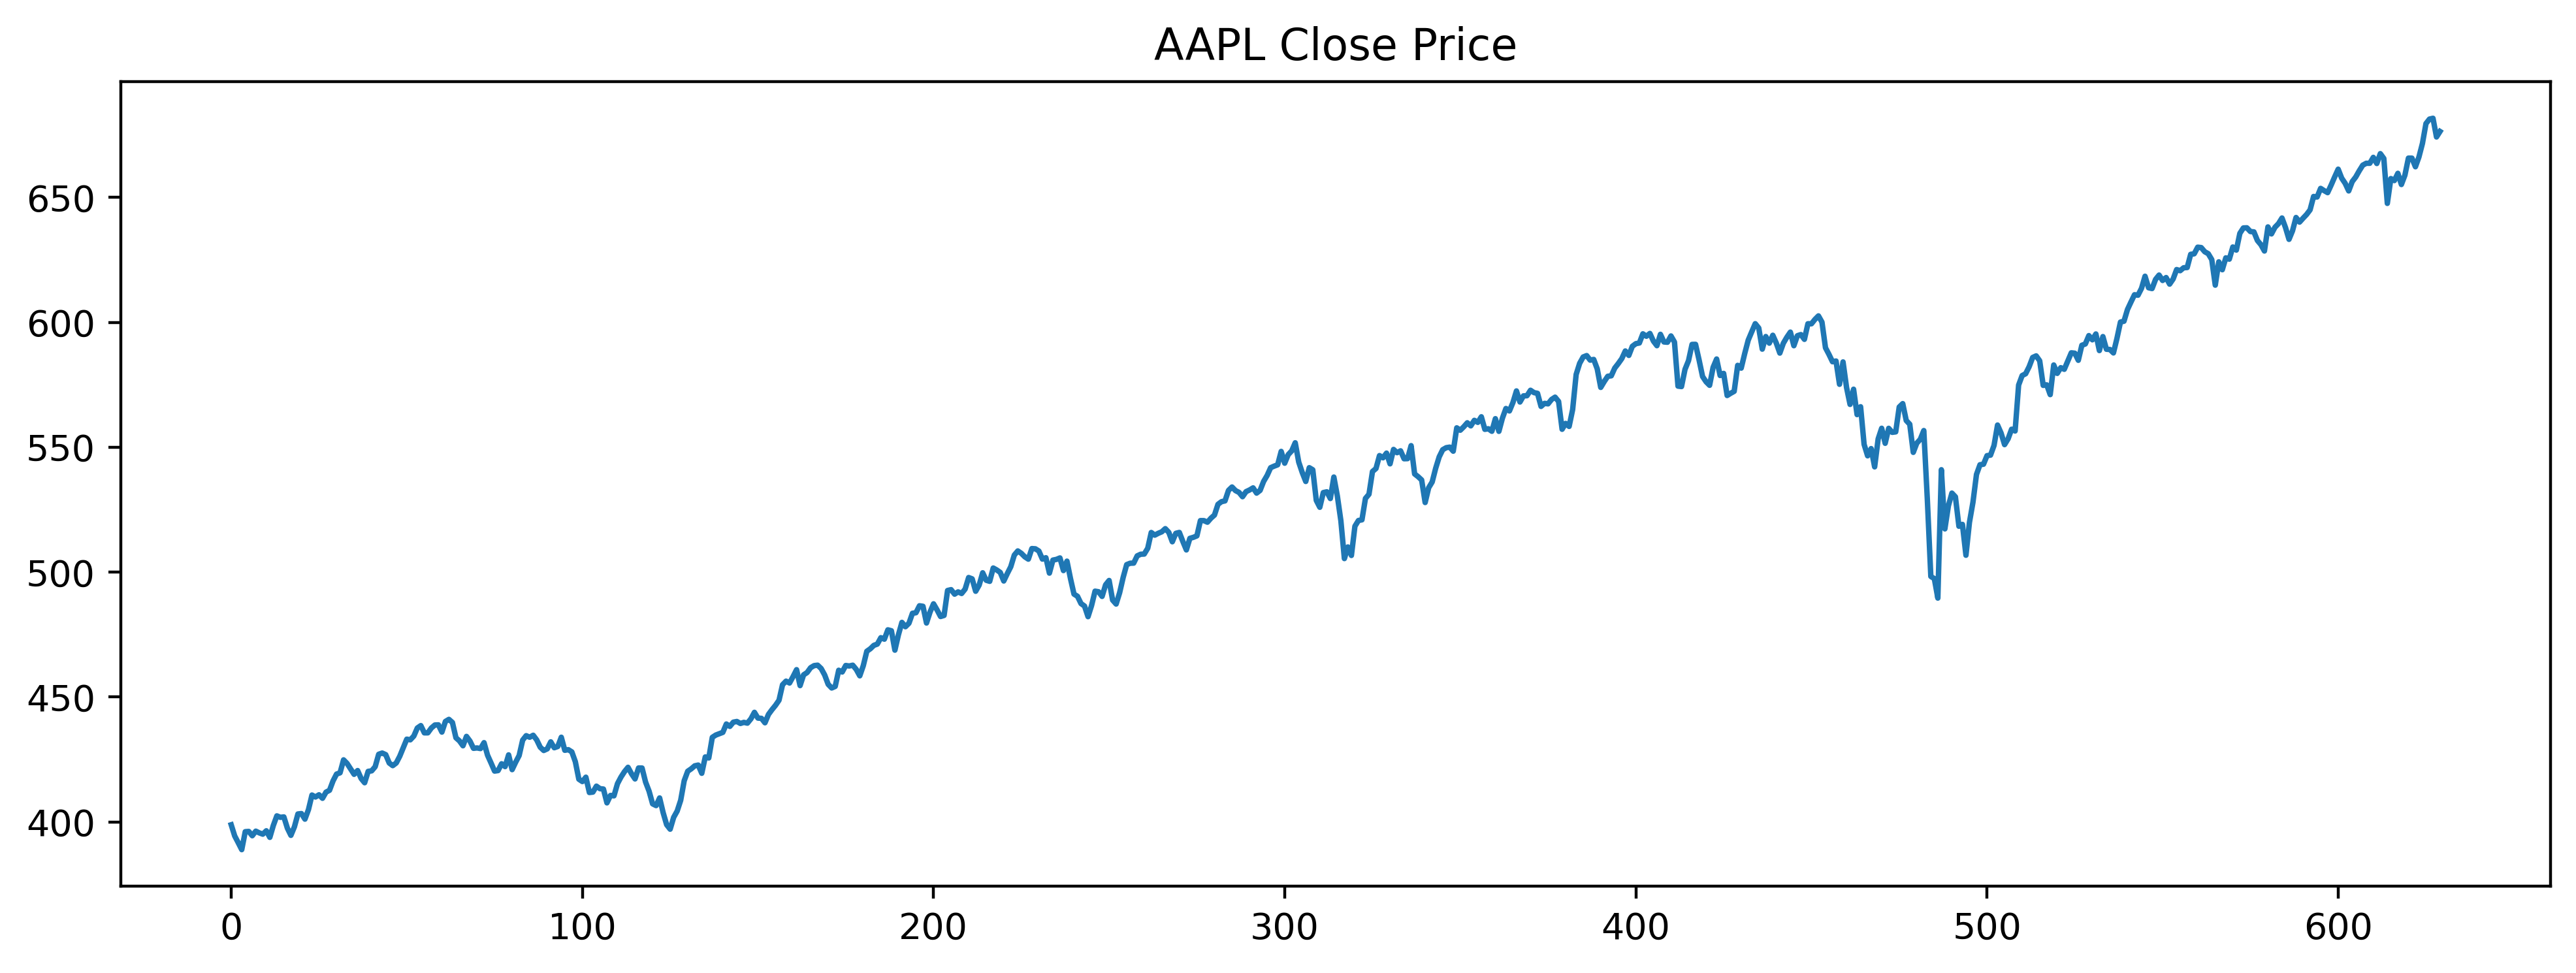

In [114]:
plt.figure(figsize=(12,4), dpi=400)
plt.plot(train_prices2D)
plt.title("AAPL Close Price")
plt.show()

In [115]:
def kalman_filter_2D(prices):

  # State:
  # x = [price, velocity]

  x = np.array([
      prices[0],
      0
  ])


  # State uncertainty
  P = np.array([
      [1,0],
      [0,1]
  ])


  # Transition matrix
  F = np.array([
      [1,1],
      [0,1]
  ])


  # We observe only price
  H = np.array([
      [1,0]
  ])


  # Process noise
  Q = np.array([
      [0.001,0],
      [0,0.001]
  ])


  # Measurement noise
  R = np.array([
      [10]
  ])

  estimates=[]


  # ----------------
  # Prediction
  # ----------------

  def predict(x, F, P, Q):
    x = F @ x
    P = F @ P @ F.T + Q
    return x, P


  # ----------------
  # Update
  # ----------------

  def update(x, P, H, R, z):

    error = z - H @ x
    S = H @ P @ H.T + R

    K = P @ H.T @ np.linalg.inv(S)
    x = x + K @ error
    P = (1- K@H)@P

    return x, P



  for price in prices:

      x, P = predict(x, F, P, Q)

      z = np.array([
          price
      ])

      x, P = update(x, P, H, R, z)


      estimates.append(x.copy())


  return np.array(estimates)

In [116]:
states2D = kalman_filter_2D(train_prices2D)

kalman_price2D = states2D[:,0]

last_state = states2D[-1]

velocity = states2D[:,1]

print("The last state is: ",last_state)

The last state is:  [ 6.76455627e+02 -1.74027031e-01]


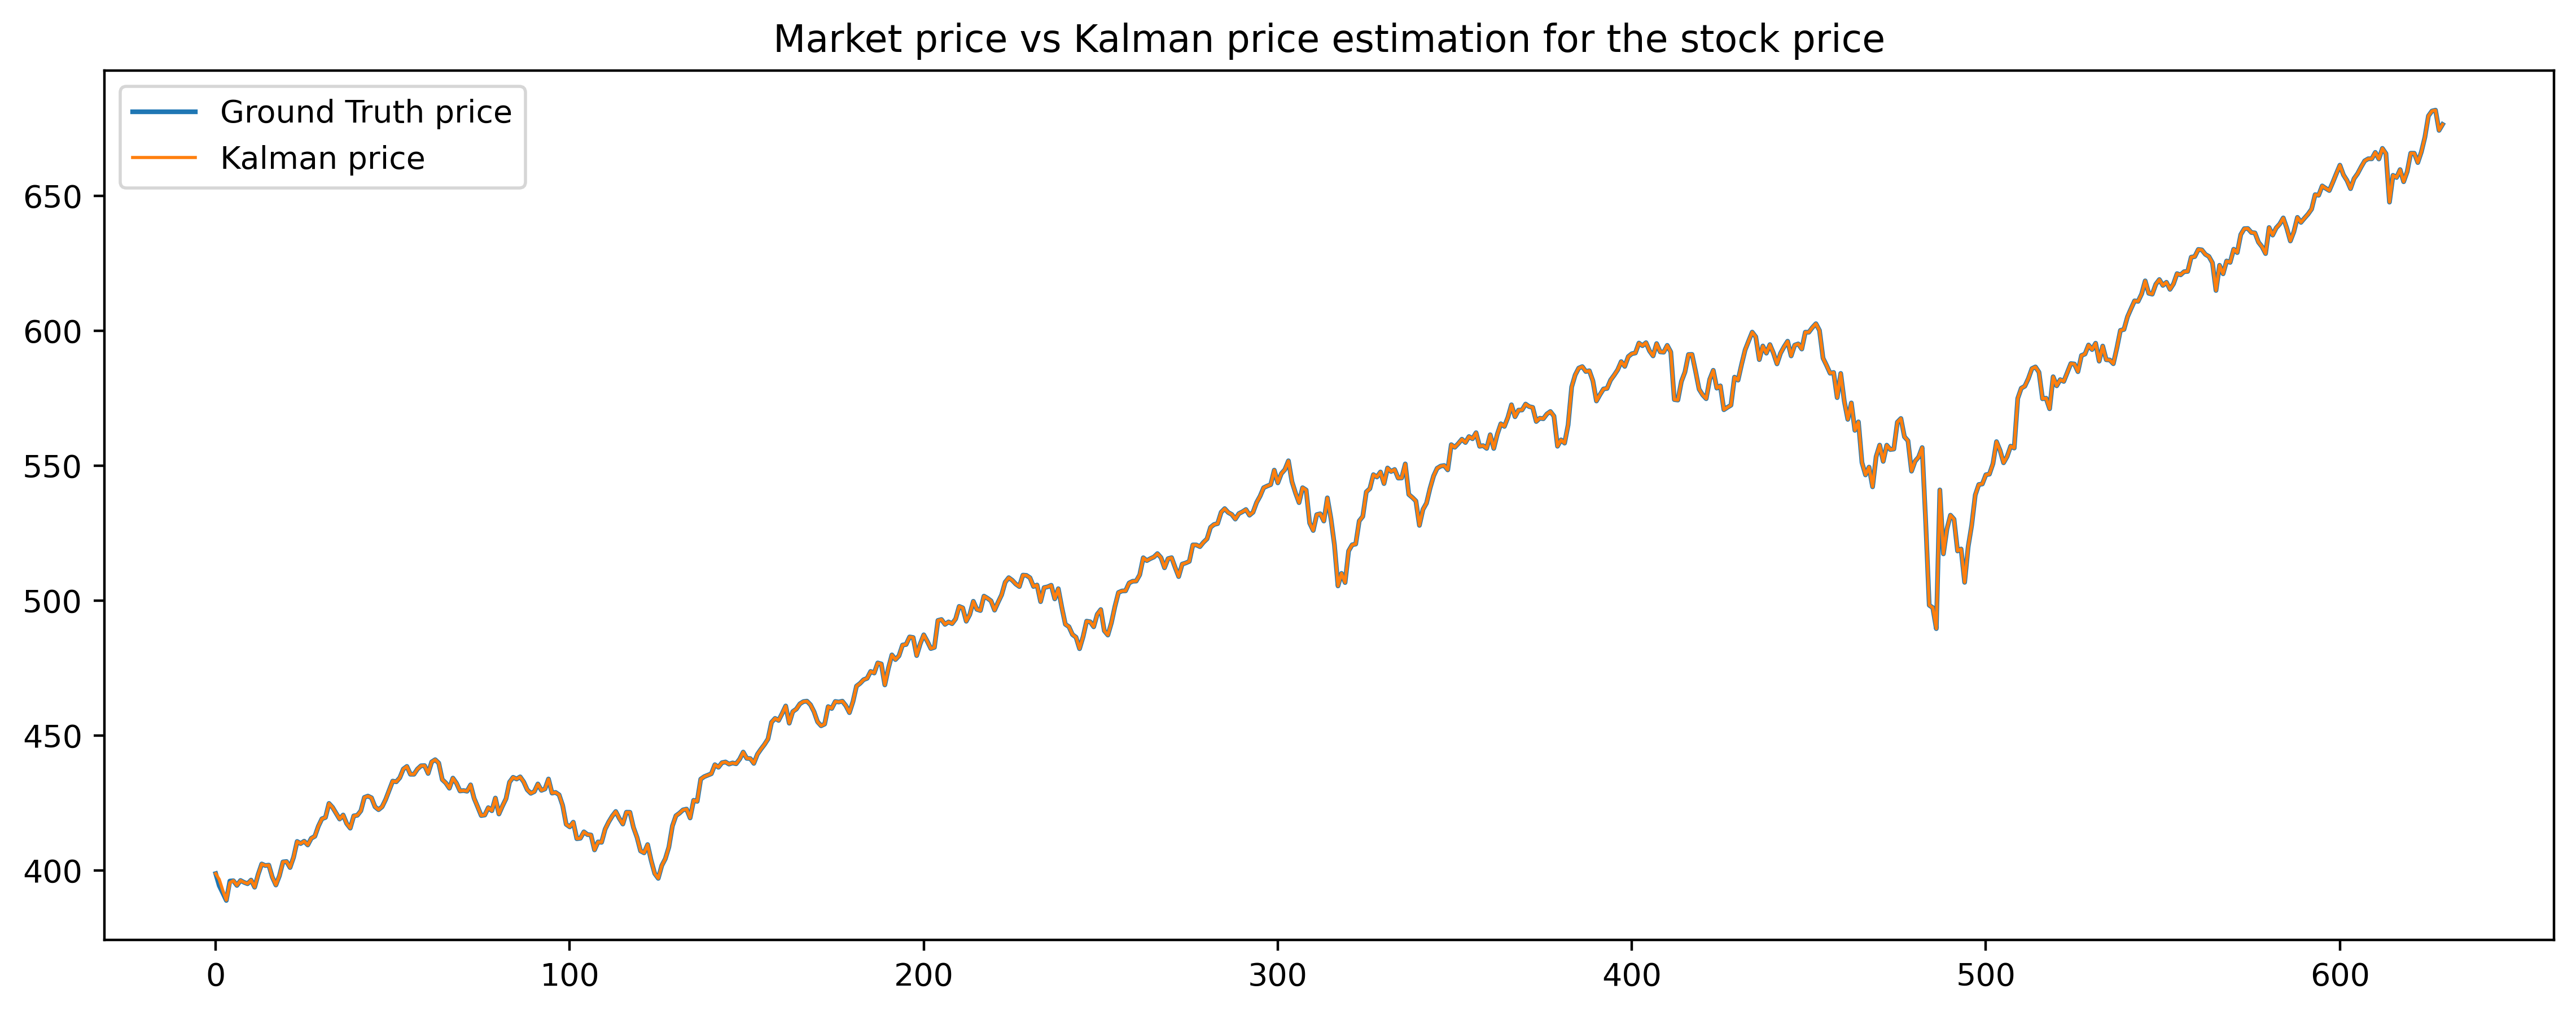

In [117]:
# Plot the estimated price

plt.figure(figsize=(14,5), dpi=400)

plt.plot(
    train_prices2D,
    alpha=1,
    label="Ground Truth price"
)

plt.plot(
    kalman_price2D,
    linewidth=1,
    label="Kalman price"
)

plt.title("Market price vs Kalman price estimation for the stock price")
plt.legend()
plt.show()

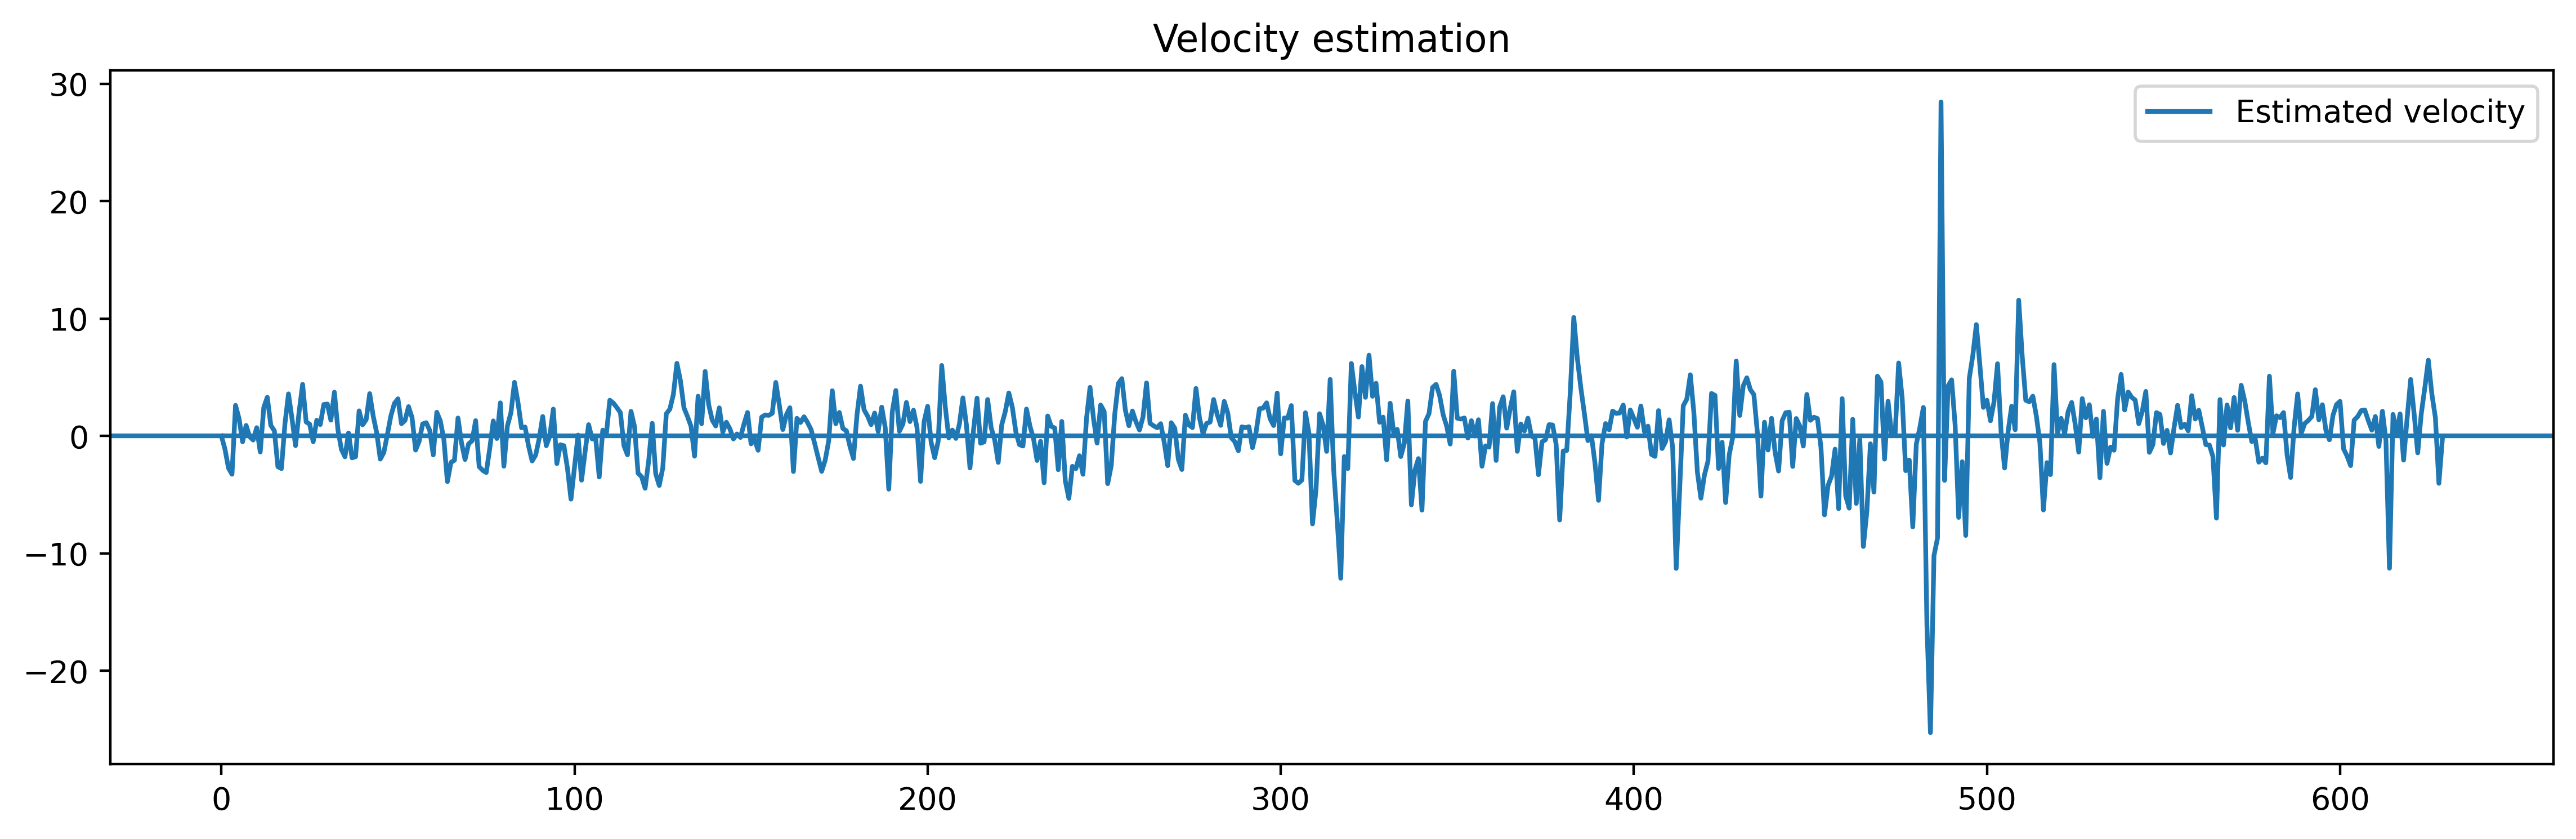

In [118]:
# Plot the estimated velocity

plt.figure(figsize=(14,4), dpi=400)

plt.plot(
    velocity,
    label="Estimated velocity"
)

plt.axhline(
    0
)

plt.title("Velocity estimation")
plt.legend()
plt.show()

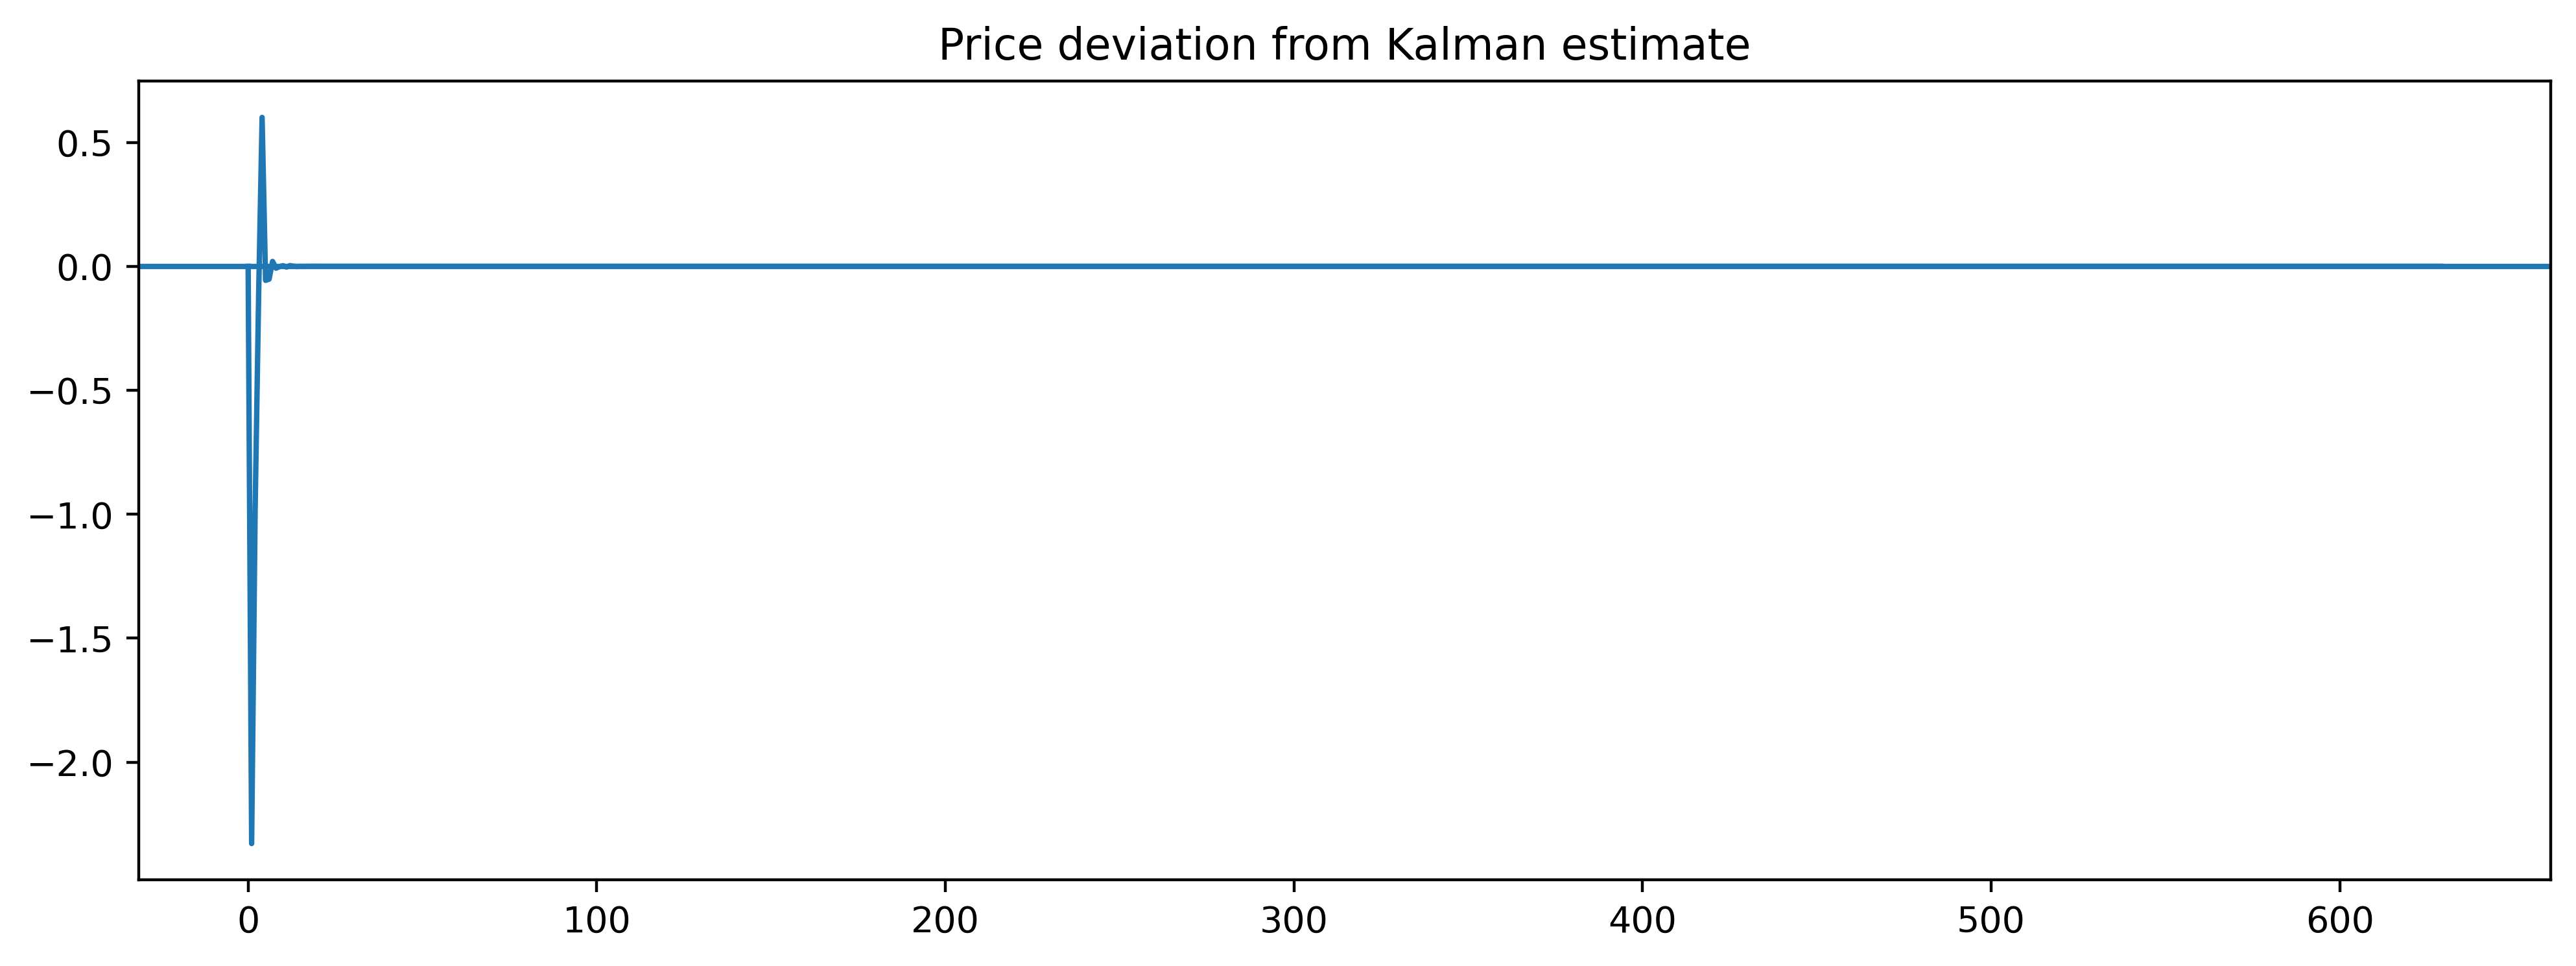

In [119]:
# Price deviation

spread = train_prices2D - kalman_price2D

plt.figure(figsize=(12,4), dpi= 400)

plt.plot(spread)

plt.axhline(0)

plt.title(
    "Price deviation from Kalman estimate"
)

plt.show()

## Step 1:  **_Build a profitable trading strategy_**

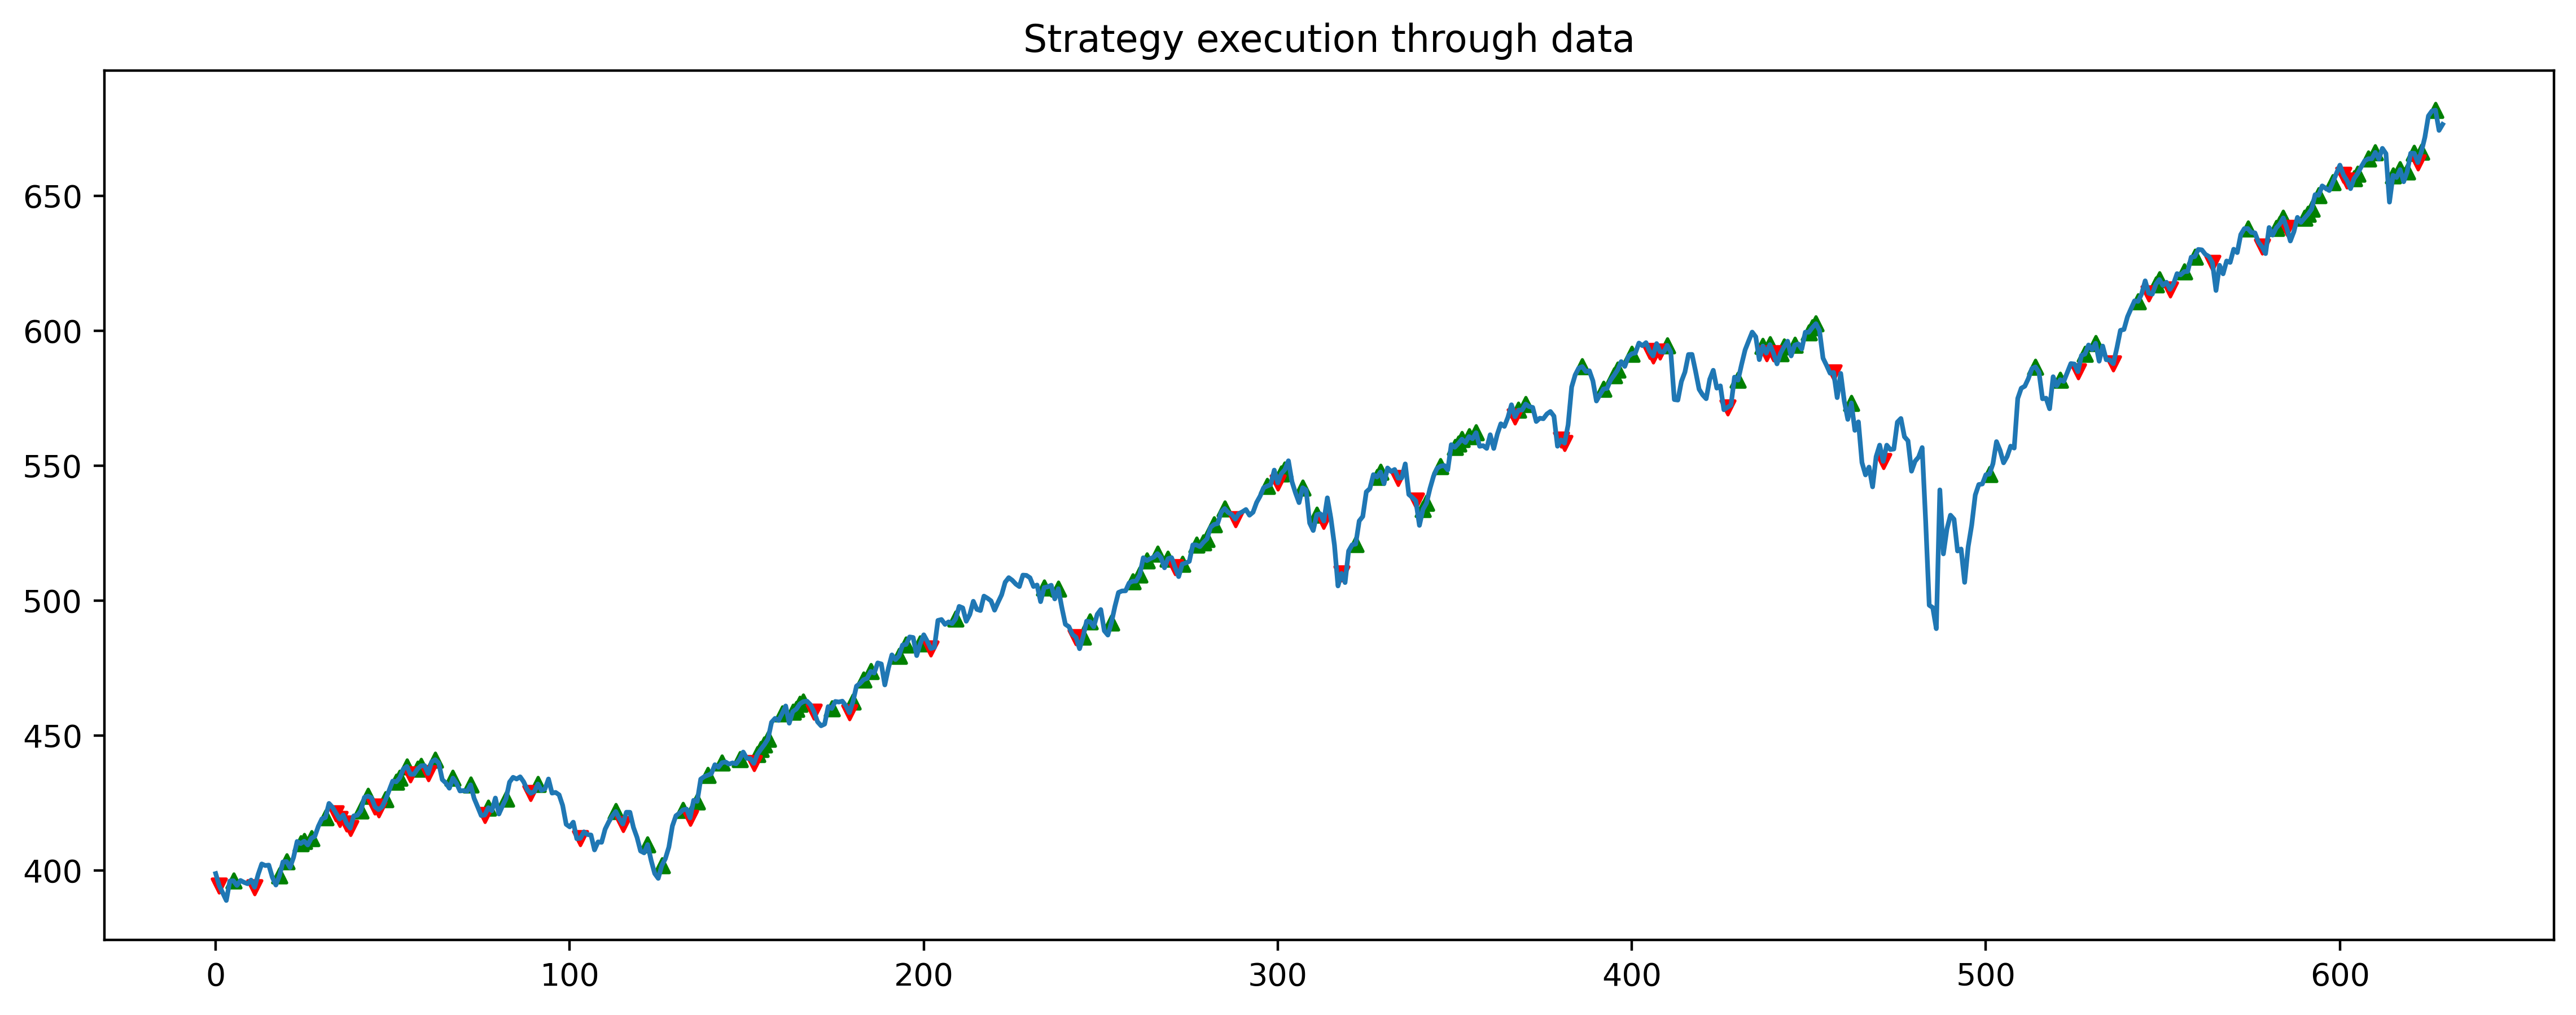

In [120]:
# Let's now generate signals

signals = np.zeros(len(train_prices2D))

# Buy:
# price below estimate
# AND trend positive

threshold_buy = 2
threshold_sell = -2

#signals[ (spread < 0) & (velocity > 0)] = 1
signals[ (1 < velocity ) & (velocity < 2)] = 1

# Sell:
#signals[ (spread > 0) & (velocity < 0)] = -1
signals[(-2 < velocity ) & (velocity < -1 )] = -1


Start= -200

plt.figure(figsize=(14,5), dpi= 400)

plt.plot(train_prices2D, alpha=1)

plt.scatter( np.where(signals==1)[0][Start:], train_prices2D[signals==1][Start:], marker="^", c='g', s=20)

plt.scatter( np.where(signals==-1)[0][Start:], train_prices2D[signals==-1][Start:], marker="v", c='r', s=20)
plt.title("Strategy execution through data")
plt.show()


In [121]:
# Now let's make a forecast the future price of the stock

steps = 10    # The number of steps to predict

def forecast_kalman2D(state, steps):

    F = np.array([
        [1,1],
        [0,1]
    ])

    predictions=[]

    x  = state.copy()

    for i in range(0,steps):
        x = F @ x
        predictions.append(
            x.copy()
        )
    return np.array(predictions)


future = forecast_kalman2D(
    last_state,
    steps
)

future_prices = future[:,0]

print(future_prices)

[676.28160041 676.10757338 675.93354635 675.75951932 675.58549229
 675.41146526 675.23743822 675.06341119 674.88938416 674.71535713]


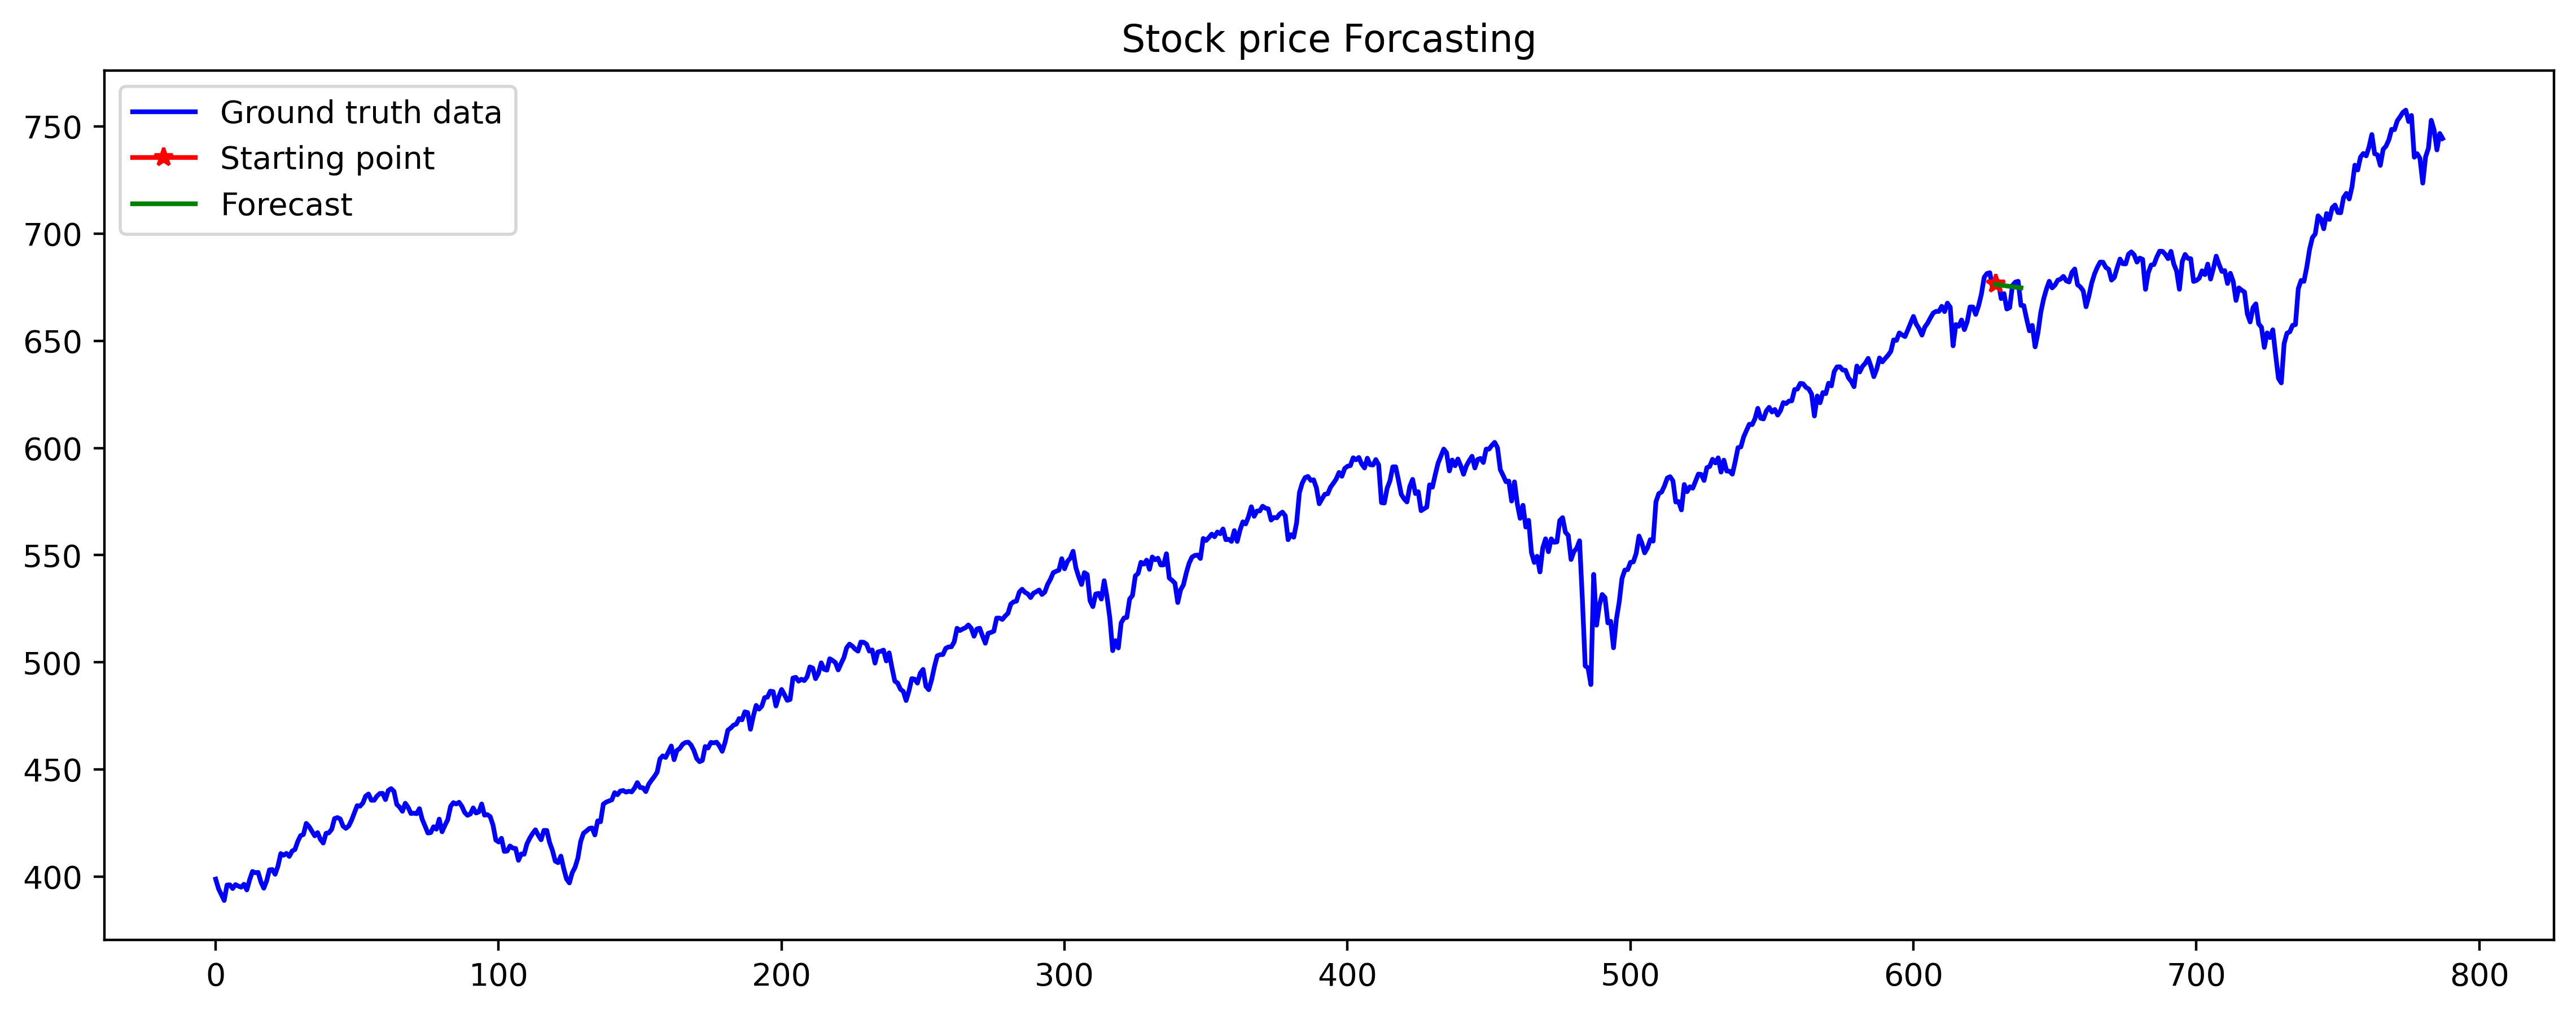

In [122]:
plt.figure(figsize=(14,5), dpi= 400)


plt.plot(
    prices2D,
     c="b",
    label="Ground truth data"
)


future_index = np.arange( len(train_prices2D)-1, len(train_prices2D)+len(future_prices)-1 )
# future_data = np.append(train_prices2D, future_prices)

plt.plot(
    len(train_prices2D)-1,
    train_prices2D[-1],
    label="Starting point",
    marker= "*",
    c='r'

)

plt.plot(
    future_index,
    future_prices,
    c="g",
    label="Forecast"
)

plt.title("Stock price Forcasting")
plt.legend()
plt.show()

In [130]:
print(test_prices2D[:steps],"\n", future_prices, "\n", np.mean(test_prices2D[:steps] - future_prices) )

[677.72515869 669.69171143 672.01245117 664.80218506 665.45672607
 675.84075928 677.38787842 677.76477051 666.51800537 666.40887451] 
 [676.28160041 676.10757338 675.93354635 675.75951932 675.58549229
 675.41146526 675.23743822 675.06341119 674.88938416 674.71535713] 
 -4.13762672029925


In [126]:
# Let's see now calculate the accuracy

accuracy = np.mean(
    test_prices2D[:steps] == future_prices
)


print(
    "Direction accuracy:",
    round(accuracy * 100, 2), " %"
)

Direction accuracy: 0.0  %
